# Deutsch–Jozsa

A promise function $f:\{0,1\}^n\to\{0,1\}$ is either **constant** (the same
bit on every input) or **balanced** (exactly half the inputs map to $0$).
Classically you may need $2^{n-1}+1$ evaluations. The quantum circuit uses
**one** oracle call.

Here $n=2$. After $H^{\otimes n}$ on the inputs, the phase-kickback oracle,
and another $H^{\otimes n}$, measuring the all-zero string means constant;
anything else means balanced.

Qiskit prints qubit 0 on the **right**. This notebook does not import the
sibling `.py` file.

In [1]:
import sys
print(sys.executable)

/home/qi/source/repos/qimono-repos/qu/qiskit/.venv/bin/python


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

N = 2
ANCILLA = N
print("classical worst case", 2 ** (N - 1) + 1, "queries")

classical worst case 3 queries


## Oracles

$U_f$ implements $|x\rangle|y\rangle \mapsto |x\rangle|y\oplus f(x)\rangle$
on $n$ input qubits plus one ancilla.

- constant $0$: identity
- constant $1$: $X$ on the ancilla
- balanced $f(x)=x_0$: CNOT from qubit $0$ onto the ancilla
- balanced $f(x)=x_0\oplus x_1$: two CNOTs (parity)

In [2]:
def oracle_constant_0() -> QuantumCircuit:
    return QuantumCircuit(N + 1, name="f=0")


def oracle_constant_1() -> QuantumCircuit:
    qc = QuantumCircuit(N + 1, name="f=1")
    qc.x(ANCILLA)
    return qc


def oracle_lsb() -> QuantumCircuit:
    qc = QuantumCircuit(N + 1, name="f=x0")
    qc.cx(0, ANCILLA)
    return qc


def oracle_parity() -> QuantumCircuit:
    qc = QuantumCircuit(N + 1, name="f=x0⊕x1")
    qc.cx(0, ANCILLA)
    qc.cx(1, ANCILLA)
    return qc


ORACLES = {
    "constant-0": ("constant", oracle_constant_0),
    "constant-1": ("constant", oracle_constant_1),
    "balanced-lsb": ("balanced", oracle_lsb),
    "balanced-parity": ("balanced", oracle_parity),
}

## Circuit

Prepare the ancilla in $|-\rangle$ ($X$ then $H$), Hadamard the inputs,
apply $U_f$, Hadamard the inputs again, measure only the $n$ inputs.

In [3]:
def deutsch_jozsa(oracle: QuantumCircuit) -> QuantumCircuit:
    qc = QuantumCircuit(N + 1, N)
    qc.x(ANCILLA)
    qc.h(range(N + 1))
    qc.compose(oracle, inplace=True)
    qc.h(range(N))
    qc.measure(range(N), range(N))
    return qc


def p_all_zero(oracle: QuantumCircuit) -> float:
    qc = QuantumCircuit(N + 1)
    qc.x(ANCILLA)
    qc.h(range(N + 1))
    qc.compose(oracle, inplace=True)
    qc.h(range(N))
    probs = Statevector.from_instruction(qc).probabilities_dict()
    return sum(float(p) for bits, p in probs.items() if bits[-N:] == "0" * N)


qc = deutsch_jozsa(oracle_parity())
print(qc.draw())

     ┌───┐          ┌───┐     ┌─┐   
q_0: ┤ H ├───────■──┤ H ├─────┤M├───
     ├───┤       │  └───┘┌───┐└╥┘┌─┐
q_1: ┤ H ├───────┼────■──┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐└───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├┤ X ├┤ X ├──────╫──╫─
     └───┘└───┘└───┘└───┘      ║  ║ 
c: 2/══════════════════════════╩══╩═
                               0  1 


## Verdict

$P(|00\rangle)\approx 1$ means constant. Near $0$ means balanced.

constant-0         promise=constant  P(|00>)=1.000  guess=constant  shots={'00': 1024}


constant-1         promise=constant  P(|00>)=1.000  guess=constant  shots={'00': 1024}
balanced-lsb       promise=balanced  P(|00>)=0.000  guess=balanced  shots={'01': 1024}


balanced-parity    promise=balanced  P(|00>)=0.000  guess=balanced  shots={'11': 1024}


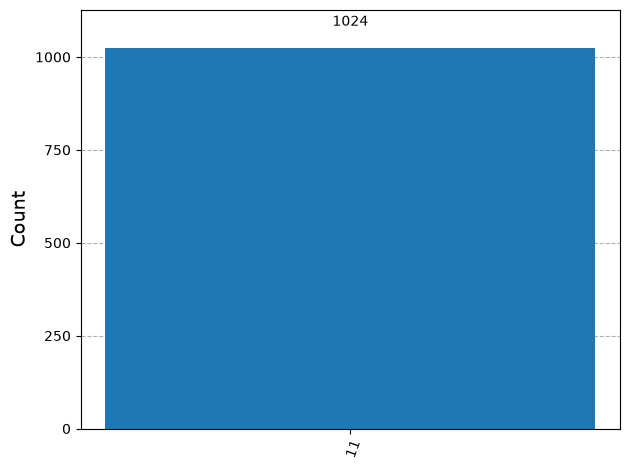

In [4]:
backend = AerSimulator()
last_counts = None
for name, (promise, factory) in ORACLES.items():
    oracle = factory()
    p0 = p_all_zero(oracle)
    guess = "constant" if p0 > 0.5 else "balanced"
    qc = deutsch_jozsa(oracle)
    last_counts = backend.run(transpile(qc, backend), shots=1024).result().get_counts()
    print(f"{name:18} promise={promise:8}  P(|00>)={p0:.3f}  guess={guess}  shots={last_counts}")

plot_histogram(last_counts)